# Análisis de Fuga de Talento

## Estrategia ABC Corp

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid")
df = pd.read_csv('../Base_Datos/df_final.csv')

### ¿TENEMOS REALMENTE UN PROBLEMA?

#### El primer paso es dimensionar la hemorragia de talento. ¿Cuál es la tasa de rotación actual y cómo se distribuye la satisfacción?

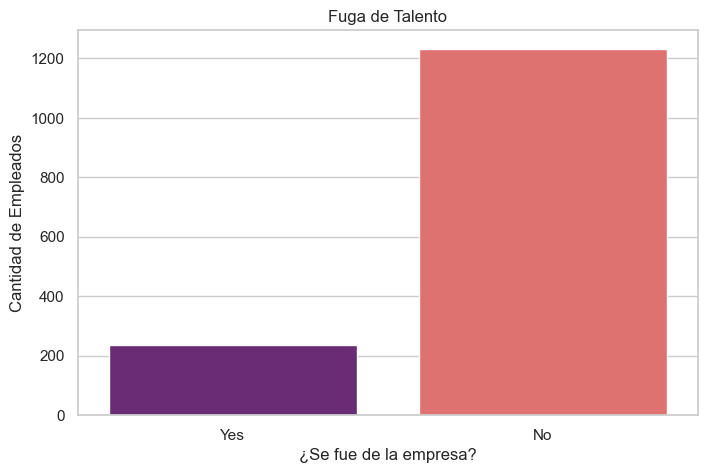

Tasa de Rotación Global: 16.12%


In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Attrition', hue='Attrition', palette='magma', legend=False)
plt.title('Fuga de Talento')
plt.xlabel('¿Se fue de la empresa?')
plt.ylabel('Cantidad de Empleados')
plt.show()

# Cálculo de la tasa
tasa_rotacion = (df['Attrition_flag'].mean() * 100)
print(f"Tasa de Rotación Global: {tasa_rotacion:.2f}%")

Tenemos una tasa de rotación del 16.12%. En una empresa saludable, este número suele rondar el 10%. Esto confirma que sí tenemos un problema. No es una métrica alarmante de crisis total, pero es lo suficientemente alta para erosionar los márgenes operativos y la moral del equipo.

--------------------------

### ¿QUIÉNES SE VAN?

#### Segmentar para entender si perdemos experiencia o potencial. ¿Es la edad un factor determinante en la decisión de irse?

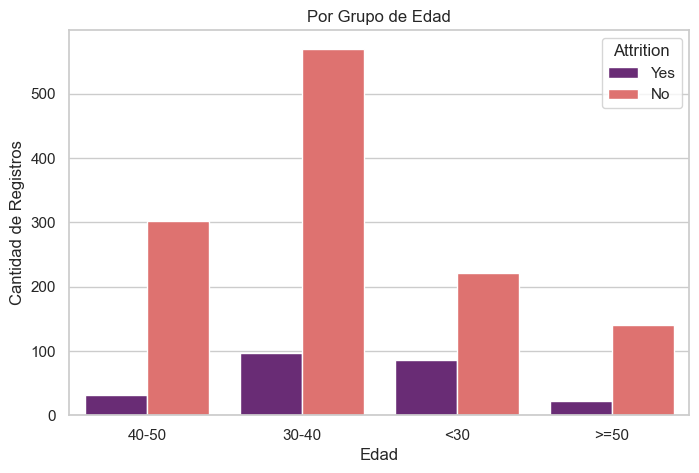

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='AgeGroup', hue='Attrition', palette='magma')
plt.title('Por Grupo de Edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Registros')
plt.show()

El grupo de menores de 30 años muestra la mayor vulnerabilidad. Mientras que en empleados senior la rotación es baja, en los jóvenes el "Yes" es proporcionalmente mucho más alto. Estamos fallando en retener el talento joven, lo que pone en riesgo el relevo generacional de la empresa.

#### ¿Influye el estado civil en la estabilidad del empleado?

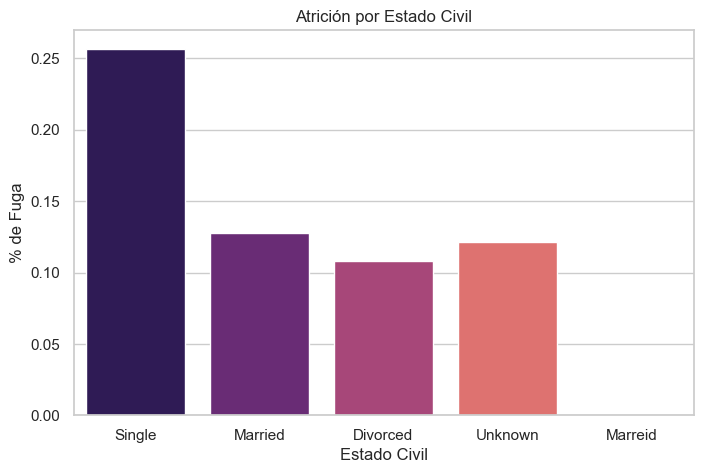

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='MaritalStatus', y='Attrition_flag', hue='MaritalStatus', palette='magma', errorbar=None, legend=False)
plt.title('Atrición por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('% de Fuga')
plt.show()

Aqui vemos que los solteros se van mas ya que no están atados a responsabilidades familiares pero sí al equilibrio vida-trabajo. Programas de "Social Hub" o flexibilidad, podrian ayudar a una mayor retencion de ese personal.

----------------------

### ¿EL TRABAJO EN SÍ ES EL PROBLEMA?

#### ¿Es lo que hacen o cómo se sienten haciéndolo? - ¿Existe una relación directa entre la satisfacción laboral y la fuga?

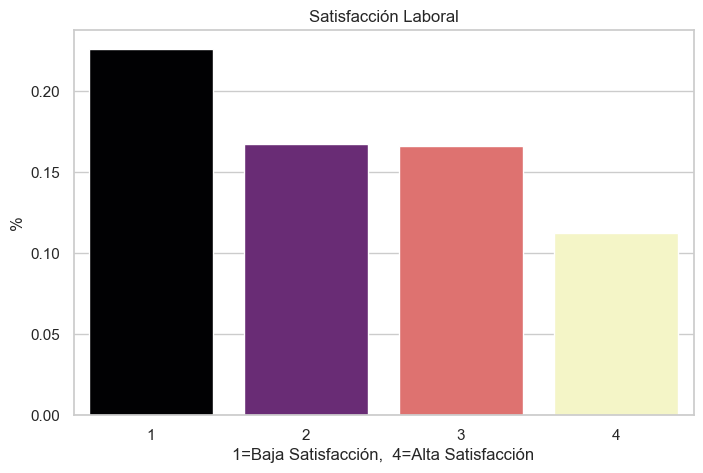

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='JobSatisfaction', y='Attrition_flag', hue='JobSatisfaction', palette='magma', errorbar=None, legend=False)
plt.title('Satisfacción Laboral')
plt.xlabel('1=Baja Satisfacción,  4=Alta Satisfacción')
plt.ylabel('%')
plt.show(True)

Un empleado "Muy Insatisfecho" tiene el doble de probabilidad de abandonar la empresa que uno "Muy Satisfecho". Sin embargo, incluso en niveles de satisfacción 2 y 3 hay rotación, lo que sugiere que hay factores externos más allá del gusto por el puesto.

#### ¿Es el salario competitivo para los que se van?

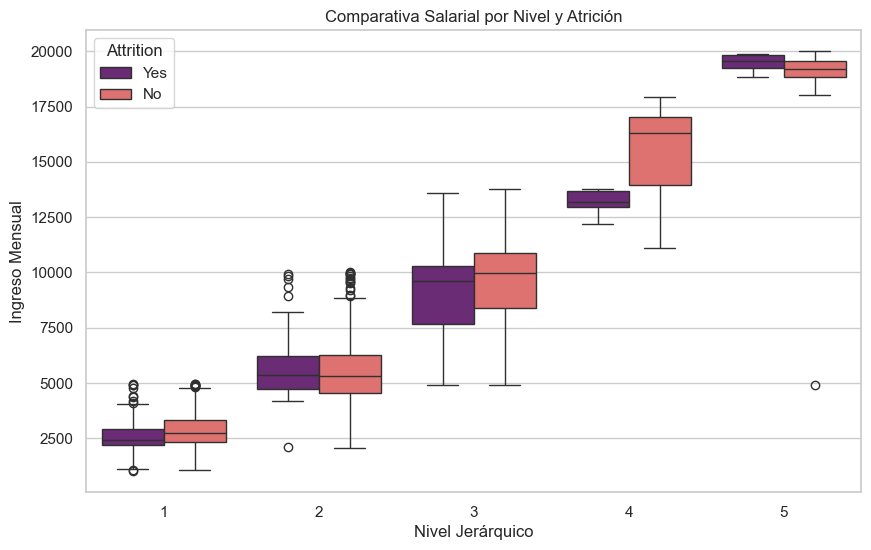

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='JobLevel', y='MonthlyIncome', hue='Attrition', palette='magma')
plt.title('Comparativa Salarial por Nivel y Atrición')
plt.xlabel('Nivel Jerárquico')
plt.ylabel('Ingreso Mensual')
plt.show()

En el Nivel 1, los empleados que se fueron ganaban significativamente menos que los que decidieron quedarse. Esto indica que en niveles base, la fuga es por mercado: se van por ofertas que pagan ligeramente mejor. En el Nivel 4 también vemos una brecha peligrosa.

--------------------------

### ¿ES EL LIDERAZGO O EL CRECIMIENTO?

Evaluamos la relación con el mando medio y las promociones. ¿Cuánto tiempo pasan con su jefe y hace cuánto no tienen un ascenso?

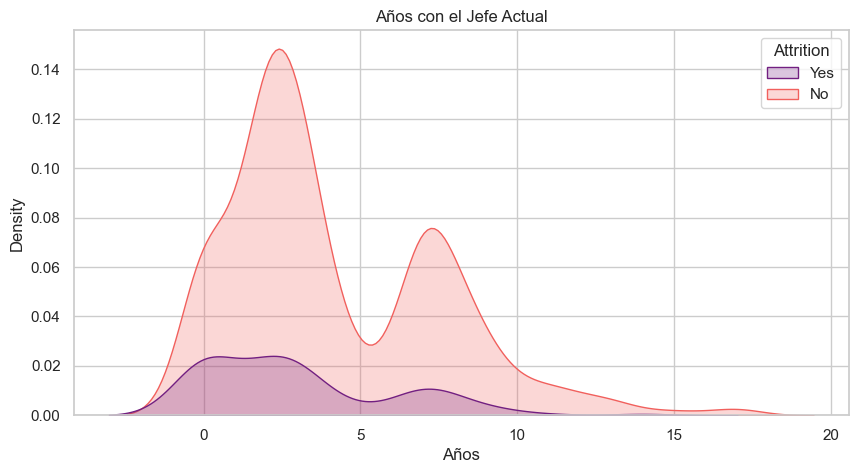

In [32]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='YearsWithCurrManager', hue='Attrition', fill=True, palette='magma')
plt.title('Años con el Jefe Actual')
plt.xlabel('Años')
plt.show()


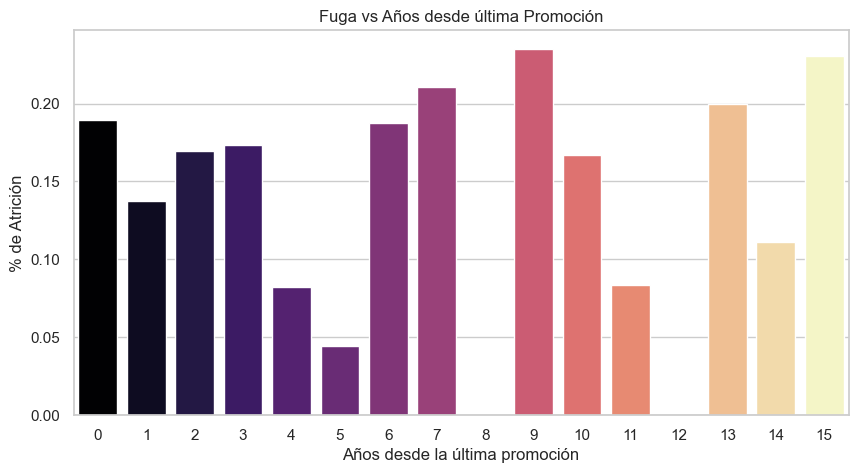

In [31]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='YearsSinceLastPromotion', y='Attrition_flag', hue='YearsSinceLastPromotion', palette='magma', errorbar=None, legend=False)
plt.title('Fuga vs Años desde última Promoción')
plt.xlabel('Años desde la última promoción')
plt.ylabel('% de Atrición')
plt.show()

La mayor fuga ocurre en los primeros 2 años con un nuevo jefe. Además, hay picos de salida cuando el empleado siente que se ha "estancado" (más de 7 años sin promoción). No solo es el dinero, es la falta de horizonte.

--------------

### ¿EL ENTORNO PERSONAL IMPORTA?

#### Factores externos que impactan la decisión interna. ¿Es la distancia al hogar un factor de riesgo para la rotación?

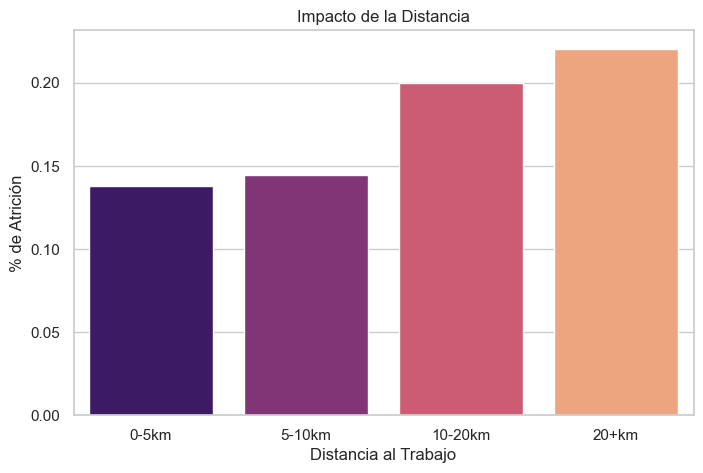

In [18]:
# Creando rangos de distancia para visualizar mejor
df['Distancia_Cat'] = pd.cut(df['DistanceFromHome'], bins=[0, 5, 10, 20, 100], labels=['0-5km', '5-10km', '10-20km', '20+km'])

plt.figure(figsize=(8, 5))
# Corregido: Asignamos x a hue y legend=False para evitar el FutureWarning
sns.barplot(data=df, x='Distancia_Cat', y='Attrition_flag', hue='Distancia_Cat', palette='magma', errorbar=None, legend=False)
plt.title('Impacto de la Distancia')
plt.xlabel('Distancia al Trabajo')
plt.ylabel('% de Atrición')
plt.show()

A partir de los 10km de distancia, la tasa de salida sube por encima del 20%. Quienes viven a más de 20km son los más propensos a irse. El traslado diario es un factor de desgaste silencioso pero crítico para la retención.

-----------------------

### ¿DÓNDE SE COMBINAN LOS FACTORES DE RIESGO?

#### ¿Dónde está el incendio real? Y ¿Cómo afecta el trabajar Horas Extra (OverTime) a los diferentes grupos de edad?

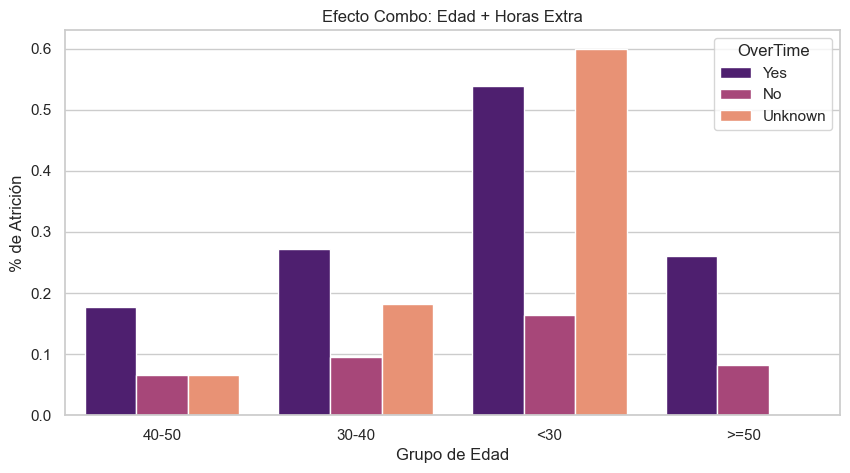

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='AgeGroup', y='Attrition_flag', hue='OverTime', palette='magma', errorbar=None)
plt.title('Efecto Combo: Edad + Horas Extra')
plt.xlabel('Grupo de Edad')
plt.ylabel('% de Atrición')
plt.show()

Este es el gráfico más revelador. Los jóvenes que hacen horas extra se van de forma masiva. Mientras que los empleados de 40-50 años toleran mejor el OverTime, en el talento joven la probabilidad de fuga se dispara cuando se les exige tiempo adicional.

----------------

### ¿QUÉ PUEDE HACER LA EMPRESA?